# Filtro Alfa-Beta: Rastreamento de Aeronave com Velocidade Constante

Este notebook demonstra a aplicação do **filtro alfa-beta** (uma simplificação do filtro de Kalman)
para estimar a posição e velocidade de uma aeronave a partir de medições de radar.

## Contexto do problema

- Uma aeronave voa em **altura constante** e se move com **velocidade aproximadamente constante**.
- Um radar realiza medições de **alcance** (distância) com ruído.
- O objetivo é estimar a **posição** e **velocidade** reais da aeronave, filtrando o ruído das medições.

## Modelo do Filtro Alfa-Beta

O filtro alfa-beta é um estimador de ordem zero para o estado (posição) e ordem um para a
velocidade. Ele alterna entre duas etapas:

### 1. Predição

$$\hat{x}_{k|k-1} = \hat{x}_{k-1|k-1} + \Delta t \cdot \hat{v}_{k-1|k-1}$$

$$\hat{v}_{k|k-1} = \hat{v}_{k-1|k-1}$$

### 2. Correção (atualização)

$$\hat{x}_{k|k} = \hat{x}_{k|k-1} + \alpha \cdot (z_k - \hat{x}_{k|k-1})$$

$$\hat{v}_{k|k} = \hat{v}_{k|k-1} + \frac{\beta}{\Delta t} \cdot (z_k - \hat{x}_{k|k-1})$$

Onde:
- $z_k$ é a medição do radar no passo $k$
- $\alpha$ controla o peso da correção na **posição** (0 = ignora medição, 1 = segue medição)
- $\beta$ controla o peso da correção na **velocidade**
- $\Delta t$ é o intervalo entre medições

## 1. Imports e configuração

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 2. Carregamento dos dados

In [2]:
RAIZ = Path().resolve().parent.parent
CAMINHO = RAIZ / "arquivos" / "exemplo2_aeronave_vconst.csv"

df = pd.read_csv(CAMINHO)

## 3. Parâmetros do filtro

| Parâmetro | Valor | Significado |
|-----------|-------|-------------|
| $\alpha$ | 0.2 | Ganho de posição (baixo = mais suavização) |
| $\beta$ | 0.1 | Ganho de velocidade (baixo = mais suavização) |
| $\Delta t$ | 5.0 s | Intervalo entre medições do radar |
| $x_0$ | 30 000 m | Posição inicial estimada |
| $v_0$ | 40 m/s | Velocidade inicial estimada |

In [ ]:
# Parâmetros do filtro alfa-beta
alpha = 0.2  # ganho de posição
beta = 0.1  # ganho de velocidade
dt = 5.0  # intervalo entre medições (s)

# Estado inicial estimado
x = 30_000.0  # posição (m)
v = 40.0  # velocidade (m/s)

### Exemplo: um passo de predição

Antes de rodar o filtro completo, vamos ver a **predição** para o primeiro passo:

$$\hat{x}_{1|0} = 30\,000 + 5 \times 40 = 30\,200 \text{ m}$$

In [4]:
x_pred = x + dt * v
v_pred = v

print(f"Posição prevista:  {x_pred:.1f} m")
print(f"Velocidade prevista: {v_pred:.1f} m/s")

Posição prevista:  30200.0 m
Velocidade prevista: 40.0 m/s


## 4. Execução do filtro

Percorremos cada medição do radar e aplicamos:
1. **Correção** — ajusta posição e velocidade com base no erro entre medição e previsão
2. **Predição** — projeta o estado para o próximo passo de tempo

In [10]:
x_pred = x + dt * v  # predição inicial para o primeiro passo
v_pred = v

posicoes_estimadas = []
velocidades_estimadas = []

for z in df["alcance_m"]:
    # --- Correção ---
    erro = z - x_pred  # inovação (erro de previsão)
    x = x_pred + alpha * erro  # correção de posição
    v = v_pred + beta * (erro / dt)  # correção de velocidade

    posicoes_estimadas.append(x)
    velocidades_estimadas.append(v)

    # --- Predição para o próximo passo ---
    x_pred = x + dt * v
    v_pred = v

posicoes_estimadas = np.array(posicoes_estimadas)
velocidades_estimadas = np.array(velocidades_estimadas)
medicoes = df["alcance_m"].to_numpy()

n_passos = np.arange(1, len(medicoes) + 1)

print(f"{'Passo':>5} | {'Medido (m)':>12} | {'Estimado (m)':>12} | {'Erro (m)':>10}")
print("-" * 50)
for i in range(len(medicoes)):
    erro = medicoes[i] - posicoes_estimadas[i]
    print(
        f"{n_passos[i]:5d} | {medicoes[i]:12.1f} | {posicoes_estimadas[i]:12.1f} | {erro:10.1f}"
    )

Passo |   Medido (m) | Estimado (m) |   Erro (m)
--------------------------------------------------
    1 |      30171.0 |      31256.4 |    -1085.4
    2 |      30353.0 |      31130.6 |     -777.6
    3 |      30756.0 |      31032.9 |     -276.9
    4 |      30799.0 |      30935.6 |     -136.6
    5 |      31018.0 |      30887.9 |      130.1
    6 |      31278.0 |      30914.7 |      363.3
    7 |      31276.0 |      30972.1 |      303.9
    8 |      31379.0 |      31069.0 |      310.0
    9 |      31748.0 |      31251.4 |      496.6
   10 |      32175.0 |      31532.3 |      642.7


## 5. Métricas de desempenho

In [6]:
erros = medicoes - posicoes_estimadas

rmse = np.sqrt(np.mean(erros**2))
mae = np.mean(np.abs(erros))
erro_max = np.max(np.abs(erros))

print(f"RMSE:              {rmse:.2f} m")
print(f"Erro absoluto médio: {mae:.2f} m")
print(f"Erro máximo:         {erro_max:.2f} m")

RMSE:              111.25 m
Erro absoluto médio: 81.00 m
Erro máximo:         210.89 m


## 6. Visualização dos resultados

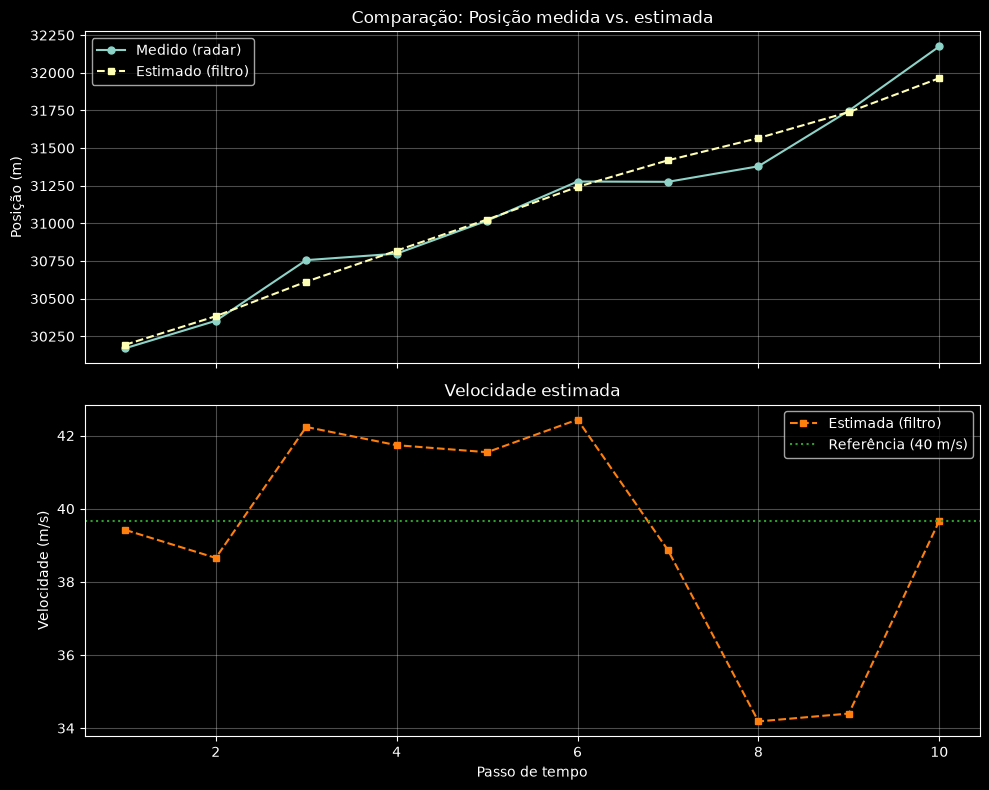

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# --- Posição ---
axes[0].plot(n_passos, medicoes, "o-", label="Medido (radar)", markersize=5)
axes[0].plot(
    n_passos, posicoes_estimadas, "s--", label="Estimado (filtro)", markersize=5
)
axes[0].set_ylabel("Posição (m)")
axes[0].set_title("Comparação: Posição medida vs. estimada")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Velocidade ---
axes[1].plot(
    n_passos,
    velocidades_estimadas,
    "s--",
    color="tab:orange",
    label="Estimada (filtro)",
    markersize=5,
)
axes[1].axhline(
    y=v, color="tab:green", linestyle=":", label=f"Referência ({v:.0f} m/s)"
)
axes[1].set_xlabel("Passo de tempo")
axes[1].set_ylabel("Velocidade (m/s)")
axes[1].set_title("Velocidade estimada")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

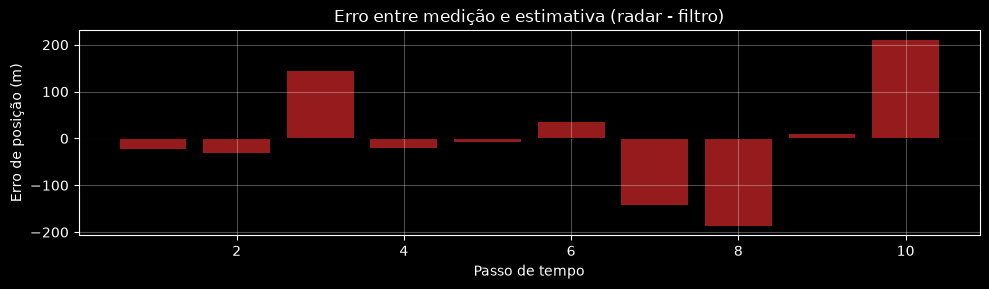

In [8]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(n_passos, erros, color="tab:red", alpha=0.7)
ax.axhline(y=0, color="black", linewidth=0.8)
ax.set_xlabel("Passo de tempo")
ax.set_ylabel("Erro de posição (m)")
ax.set_title("Erro entre medição e estimativa (radar - filtro)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()